# 야생 포켓몬 포획 성공 여부 예측 모델

**2023103381 원혜경**

## 목차

#### 1. Import Libraries
#### 2. Problem Definition
#### 3. Generate Dataset
#### 4. Data Processing
#### 5. Build Models
#### 6. Training and Visualization
#### 7. Result and Overfitting Analysis 
#### 8. Test Evaluation & Faliure Analysis
#### 9. Conclusion 

## 1. Import Libraries

In [6]:
# 기본 파이썬 유틸리티 및 환경 설정
import os
import random

# 데이터 핸들링 및 수치 연산 (NumPy, Pandas)
import numpy as np
import pandas as pd

# 시각화 (Matplotlib)
import matplotlib.pyplot as plt

# 머신러닝 전처리 및 성능 평가 (Scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 딥러닝 프레임워크 (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- 재현성 보장을 위한 시드 고정 함수 ---
def set_seed(seed=42):
    """
    모든 무작위성(Randomness)을 제어하여 조교님이 실행해도 
    동일한 결과가 나오도록 보장하는 함수입니다.
    """
    # 1. 기본 파이썬 및 해시 시드 고정
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. NumPy 시드 고정
    np.random.seed(seed)
    
    # 3. PyTorch 시드 고정 (CPU 및 GPU 모두 포함)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    # 4. CuDNN(GPU 가속 라이브러리)의 결정론적 연산 설정
    # 속도는 소폭 하락할 수 있으나 결과의 일관성을 위해 필수적입니다.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"✅ 모든 랜덤 시드가 {seed}로 고정되었습니다. 재현성이 보장됩니다.")

# 실험 시작 전 함수 호출
set_seed(42)

✅ 모든 랜덤 시드가 42로 고정되었습니다. 재현성이 보장됩니다.


## 2. Problem Definition
 - **배경 및 시나리오 :**
     - 포켓몬스터 시리즈의 핵심은 닌텐도 콘솔을 이용한 게임이며, 야생 포켓몬과 조우하여 이를 '포획'하는 것이 주된 과정입니다.<br>
     - 이 프로젝트에서는 포켓몬의 포획 공식을 결정짓는 핵심 변수들을 이용하여, 특정 상황에서의 포켓몬의 포획의 성공과 실패를 예측하는 Multi-Class 
Classification AI를 설계하고자 합니다.
   
 - **데이터셋 구성 :**
    1. HP_ratio(float) : 포켓몬의 남은 체력 비율을 0-100%로 표기합니다. 실제 게임 로직에 따라, 체력이 낮을수록 포획 확률이 상승하도록 설계해야합니다.
    2. Catch_Rate(integer): 포켓몬 종별 고유 포획 난이도로 3-255까지 존재합니다. 숫자가 작을수록 포획이 어렵습니다.
    3. Ball_Type(integer): 사용한 볼의 종류로 몬스터볼(1), 슈퍼볼(2), 하이퍼볼(3), 마스터볼(4)로 구분하고, 각각 고유 포획 보정치를 가집니다. 마스터볼은 무조건 포획이 가능하고, 몬스터 - 하이퍼로 갈 수록 포획 보정치가 상승합니다.
    4. Status(integer): 상태이상의 종류로 정상(0), 마비/화상/독(1), 잠듦/얼음(2)로 가중치를 부여합니다. 잠듦과 얼음 상태로 갈수록 포획률이 높아지도록 가중치를 부여합니다. <br>
    <br>
 -  **출력 :**
     - 0(Escape) : 포획이 실패하고 포켓몬이 볼에서 나온 상태
     - 1(Catch) : 포획을 성공한 상태
     - 2(Faint) : hp가 0이 되어 포획 기회를 상실하고 기절한 상태

## 3. Generate Dataset
포켓몬스터 내부의 포획 공식의 매커니즘을 반영하여, 가상 데이터를 생성합니다.<br>
**데이터 생성 로직:**  
1. **기절(Faint) - 우선 처리 필요**: `HP_ratio`가 0인 경우 다른 조건과 무관하게 2(Faint)로 분류합니다.
2. **확정 포획(Master Ball) 처리**: `Ball_Type`이 4(마스터볼)인 경우에는 무조건 1(Catch)로 분류합니다.
3. **확률 기반 분류**: 일반적인 상황에서 HP가 낮을수록, 포켓몬 고유 포획률(Catch_Rate)이 높을수록, 볼 성능(Ball_Type)이 좋을수록, 또한 상태이상의 가중치가 커질수록 포획 성공 확률이 높아집니다.
 - 1,2,3,4 순서대로 실제 포켓몬스터의 확률 계산 방법을 기반으로 재현하였습니다.<br>
 
- **Optional Extention - Controlled Noise:** 실제 게임의 확률적 불확실성을 재현하기 위해서 데이터에 노이즈를 추가하고, '운'이라는 요소를 모델이 학습할 수 있도록 하였습니다. 실제 게임처럼 '운'에 의해 완벽한 조건에서도 포획이 실패할 수 있고, 낮은 확률에서 성공하기도 합니다. 

--- Class Distribution ---
label
0    841
1    621
2     38
Name: count, dtype: int64


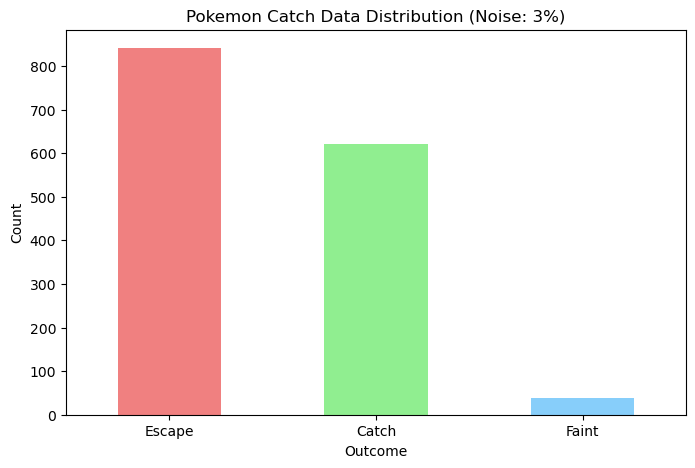

In [9]:
def generate_pokemon_data(n_samples=1500, noise_ratio=0.03):
    # 1. 재현성을 위한 Seed 고정
    rng = np.random.default_rng(42) 
    
    # 2. feature생성
    # HP_ratio: 0~100 사이에서 생성하되, 약 3%의 데이터가 기절(0) 상태가 되도록 범위를 -3부터 시작
    # 0 부터 시작하니까 0값이 안나와서 기절 분류 불가능.
    hp_ratio = rng.uniform(-3, 100, n_samples)
    hp_ratio = np.clip(hp_ratio, 0, 100) # 마이너스 값은 시각화와 처리를 위해 0으로 고정
    
    catch_rate = rng.integers(3, 256, n_samples)
    # 몬스터볼(1), 슈퍼볼(2), 하이퍼볼(3), 마스터볼(4) 비중 설정
    # 마스터볼이 많을 경우, 잘못된 학습 가능.
    ball_type = rng.choice([1, 2, 3, 4], n_samples, p=[0.4, 0.3, 0.25, 0.05])
    status = rng.integers(0, 3, n_samples) # 0:정상, 1:마비/독/화상, 2:잠듦/얼음

    X = np.column_stack([hp_ratio, catch_rate, ball_type, status])
    y = []

    # 3. 포획 로직 적용
    for hp, cr, ball, st in X:
        if hp <= 0:
            label = 2 # Faint: 체력이 0이면 기절
        elif ball == 4:
            label = 1 # Master Ball: 마스터볼은 무조건 포획
        else:
            # 보정치 설정
            ball_mod = {1: 1.0, 2: 1.5, 3: 2.0}[ball]
            status_mod = {0: 1.0, 1: 1.5, 2: 2.5}[st]
            
            # 포획 확률 계산 수식
            catch_prob = ((100 - hp) * 0.4) + (ball_mod * 15) + (status_mod * 10) + (cr * 0.1)
            
            if catch_prob > 75:
                label = 1 # Catch: 포획 성공
            else:
                label = 0 # Escape: 포획 실패
        y.append(label)

    y = np.array(y)

    # 4. 노이즈 추가 (3%)
    # 기절(2)이 아닌 데이터 중 일부의 라벨을 반전하여 확률적 예외 상황 재현
    
    n_noise = int(n_samples * noise_ratio)
    # 기절 상태는 규칙이 절대적이므로 노이즈 제외 - 기절 시 포획은 노이즈가 아닌 에러.
    # 마스터볼을 이용해서 포획이 실패하는 경우도 노이즈가 아닌 에러.
    valid_indices = np.where((y != 2) & (X[:, 2]!=4))[0] 
    noise_indices = rng.choice(valid_indices, size=n_noise, replace=False)
    for idx in noise_indices:
        y[idx] = 1 - y[idx] # 0(실패) <-> 1(성공) 반전

    return X, y

# --- 데이터 생성 및 확인 ---
feature_names = ['HP_ratio', 'Catch_Rate', 'Ball_Type', 'Status']
class_names = ['Escape', 'Catch', 'Faint']
X, y = generate_pokemon_data()

# 데이터 분포 시각화
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y
print("--- Class Distribution ---")
print(df['label'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
df['label'].value_counts().sort_index().plot(kind='bar', color=['lightcoral', 'lightgreen', 'lightskyblue'])
plt.title('Pokemon Catch Data Distribution (Noise: 3%)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=class_names, rotation=0)
plt.show()

## 4. Data Processing
학습의 객관성, 수렴 속도를 높이기 위해서 전처리를 수행하고 데이터를 분할한 후에, 표준화합니다.
- **Data Split**: 데이터를 Train(60%), Validation(20%), Test(20%)의 세 가지 세트로 분할합니다. 성공, 실패, 기절의 비율을 모든 데이터 세트에서 동일하게 유지하도록 stratify = y 옵션을 사용합니다. stratify = y 옵션을 이용하면 도망, 포획, 기절의 비율을 모든 세트에서 동일하게 유지합니다.
- **Normalization**: feature들의 평균을 0, 표준편차가 1로 변환하고자 StandardScaler를 사용합니다. 이를 통해서 각 feature의 스케일 차이에 따른 가중치의 업데이트의 불균형을 개선하고, 학습 속도를 높이고자 합니다. 이를 통해서 데이터의 의미에 집중하여 분류를 수행할 수 있도록 합니다.
- **Tensor Conversion**: NumPy 데이터를 PyTorch의 Tensor로 바꾸어 DataLoader에 담아서 Mini-batch학습을 할 수 있도록 준비합니다. Numpy 배열에서 Tensor로 변환하여 GPU 연산을 지원하고 미분을 계산하도록 합니다. 

In [11]:
# 1. 데이터셋 분할 (Train 60% / Val 20% / Test 20%)
# stratify=y 옵션은 성공/실패/기절 비율을 세 그룹에 일정하게 배분합니다.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

# 2. 표준화 (Normalization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 3. PyTorch 텐서(Tensor) 변환
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 4. DataLoader 설정 (미니배치 학습 준비)
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

print(f"Preprocessing Complete. Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Preprocessing Complete. Train: 900, Val: 300, Test: 300


## 5. Build Models
본 프로젝트에서는 모델의 Bias와 Variance의 Trade-off 관계를 분석하여, 가장 좋은 모델을 찾기 위해서 bottom-up 방식을 채택하였습니다. 이를 통해서 단순한 모델에서 점진적으로 상승하여 최적화된 모델을 찾기 위한 과정을 진행했습니다. 다만, 추가로 너무 많은 모델을 수정하고 돌려보는 과정을 다 담을 순 없기 때문에 3가지의 모델만 작성했습니다.<br>
**1. Shallow Model**<br>
  - 은닉층 1개로 구성된 최소한의 신경망 모델입니다. 
  - Variance는 낮지만, Bias가 높을 위험이 있습니다.<br>

**2. Deep Model**<br>
  - 은닉층을 3개로 늘리고 노드 수를 확장하여, 표현력을 높이고 Bias를 최소화 합니다.
  - Variance가 상승하여 검증 시 성능이 떨어지고 overfitting이 발생할 수 있습니다.
  - 본 프로젝트에서는 최적화 이전 비교군이 되는 대상입니다.<br>

**3. Optimized Model(Final)**<br>
  - 최적의 Trade-off지점을 찾기 위해서 bias와 Variance를 조절합니다.
  - Dropout을 적용하여 특정 노드에 대한 의존도를 낮추고, overfitting을 막고자 합니다.  

In [13]:
# [Stage 1] Shallow Model: 은닉층이 없는 선형 모델
class ShallowModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ShallowModel, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        # 선형 결합 후 활성화 함수(ReLU)를 적용.
        # 비선형성을 추가하기 위한 목적으로 사용.
        x = F.relu(self.fc(x))
        return x

# [Stage 2] Deep Model: Bias를 줄이기 위해 층을 깊게 설계 (과적합 위험군)
# 실제로는 이렇게까지 복잡하게 설계할 필요 없음.
class DeepModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 32)
        self.fc6 = nn.Linear(32, output_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.relu(self.fc5(x))
        x = self.fc6(x)
        return x

# [Stage 3] Optimized Model: Dropout을 적용하여 Variance를 제어한 최종 모델
class OptimizedModel(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_prob=0.4):
        super(OptimizedModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout_prob)
        self.fc3 = nn.Linear(128, output_dim)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# 입력 4개 피처, 출력 3개 클래스(Escape, Catch, Faint)
input_size = 4
output_size = 3

model_shallow = ShallowModel(input_size, output_size)
model_deep = DeepModel(input_size, output_size)
model_optimized = OptimizedModel(input_size, output_size)

print("Models for Bias-Variance analysis are initialized.")

Models for Bias-Variance analysis are initialized.


## 6. Training and Visualization
앞서 정의한 Shallow, Deep, Optimized 모델을 각각 학습시킨 후, 성능 변화를 시각화합니다. 
- **Loss Function(CrossEntropyLoss)**: Multi-class Classification 문제에서 예측값과 실제 라벨 사이의 확률 분포 차이를 계산하는데 효과적인 손실함수라 사용하였습니다.
- **Optimizer**: Adam을 이용하여 학습률을 유동적으로 조절하고, 안정적으로 수렴할 수 있도록 합니다.
- **Epochs & Learning Raate**: 모델이 데이터를 충분히 반복학습하고, 안정적으로 수렴하도록 60epochs, 0.001의 학습률을 정했습니다.

In [15]:
# 학습 진행 상황을 기록하고 평가하는 함수 정의
def evaluate_model(model, loader, criterion, device='cpu'):
    model.eval()
    total_loss = 0.0
    preds_all = []
    labels_all = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(labels_all, preds_all)
    return avg_loss, acc

def train_model(model, train_loader, val_loader, lr=0.001, epochs=60, weight_decay=0.0, device='cpu'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, preds_all, labels_all = 0.0, [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            preds_all.extend(preds.detach().cpu().numpy())
            labels_all.extend(yb.detach().cpu().numpy())

        train_loss = total_loss / len(train_loader.dataset)
        train_acc = accuracy_score(labels_all, preds_all)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device=device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

    return model, history

In [16]:
# 1. 환경 설정 및 시드 고정
device = 'cuda' if torch.cuda.is_available() else 'cpu'
set_seed(42) # 재현성을 위해 앞서 만든 함수 호출

# 데이터의 차원 확인 (X_train이 전처리된 상태여야 합니다)
input_dim = X_train.shape[1] 
output_dim = 3 # Escape, Catch, Faint

# 모델 객체 새로 생성하기
# 에러가 나서 그냥 새로 생성함.
model_shallow = ShallowModel(input_dim, output_dim).to(device)
model_deep = DeepModel(input_dim, output_dim).to(device)
model_optimized = OptimizedModel(input_dim, output_dim).to(device)

# 3. 학습 진행
print("--- Training Shallow Model (Underfitting) ---")
model_shallow, history_shallow = train_model(model_shallow, train_loader, val_loader, device=device)

print("\n--- Training Deep Model (Overfitting) ---")
model_deep, history_deep = train_model(model_deep, train_loader, val_loader, device=device)

print("\n--- Training Optimized Model (Regularized) ---")
# Optimized 모델은 일반화 성능을 위해 L2 규제(weight_decay)를 추가합니다.
model_optimized, history_optimized = train_model(model_optimized, train_loader, val_loader, weight_decay=1e-4, device=device)

✅ 모든 랜덤 시드가 42로 고정되었습니다. 재현성이 보장됩니다.
--- Training Shallow Model (Underfitting) ---
Epoch 001 | Train Loss: 1.1291 | Val Loss: 1.1371 | Train Acc: 0.3644 | Val Acc: 0.3533
Epoch 010 | Train Loss: 0.7987 | Val Loss: 0.7972 | Train Acc: 0.7544 | Val Acc: 0.7533
Epoch 020 | Train Loss: 0.6013 | Val Loss: 0.5935 | Train Acc: 0.8922 | Val Acc: 0.8833
Epoch 030 | Train Loss: 0.5096 | Val Loss: 0.4988 | Train Acc: 0.9089 | Val Acc: 0.9033
Epoch 040 | Train Loss: 0.4601 | Val Loss: 0.4472 | Train Acc: 0.9100 | Val Acc: 0.9133
Epoch 050 | Train Loss: 0.4308 | Val Loss: 0.4171 | Train Acc: 0.9144 | Val Acc: 0.9100
Epoch 060 | Train Loss: 0.4118 | Val Loss: 0.3961 | Train Acc: 0.9111 | Val Acc: 0.9100

--- Training Deep Model (Overfitting) ---
Epoch 001 | Train Loss: 0.6283 | Val Loss: 0.4589 | Train Acc: 0.7778 | Val Acc: 0.8367
Epoch 010 | Train Loss: 0.2211 | Val Loss: 0.2405 | Train Acc: 0.9278 | Val Acc: 0.9233
Epoch 020 | Train Loss: 0.1994 | Val Loss: 0.2306 | Train Acc: 0.9378 | Val Acc: 0

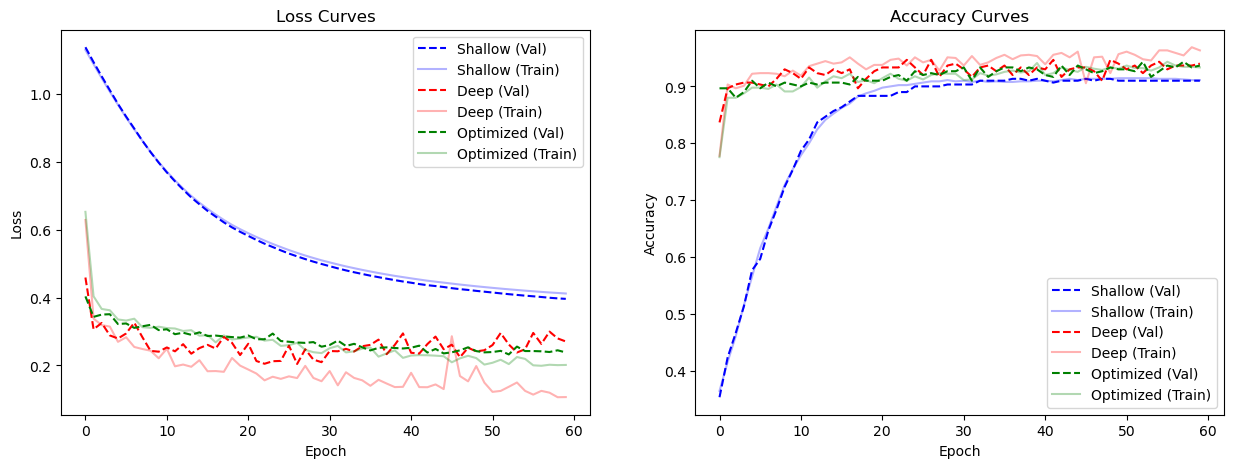

In [17]:
def plot_learning_curves(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    colors = ['blue', 'red', 'green']

    for i, (history, name) in enumerate(zip(histories, names)):
        # Loss Curve
        axes[0].plot(history['val_loss'], label=f'{name} (Val)', color=colors[i], linestyle='--')
        axes[0].plot(history['train_loss'], label=f'{name} (Train)', color=colors[i], alpha=0.3)
        # Accuracy Curve
        axes[1].plot(history['val_acc'], label=f'{name} (Val)', color=colors[i], linestyle='--')
        axes[1].plot(history['train_acc'], label=f'{name} (Train)', color=colors[i], alpha=0.3)

    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.show()

plot_learning_curves(
    [history_shallow, history_deep, history_optimized], 
    ['Shallow', 'Deep', 'Optimized']
)

## 7. Result and Overfitting Analysis

그래프 분석 결과, 모델의 복잡도와 규제 적용 여부에 따라 명확한 성능 차이가 관찰되었습니다. 특히 학습 과정에서 Bias와 Variance의 Trade-off 현상을 수치적으로 발견할 수 있었습니다.

### 7.1 모델별 최종 성능 비교 (Epoch 60 기준)

실험을 통해 얻은 각 모델의 최종 평가지표는 다음과 같습니다. (랜덤 시드는 모두 42로 고정하여 학습을 진행햐였습니다.)

| 모델 구분 | Train Acc | Val Acc | **Acc Gap** | Train Loss | Val Loss | **Loss Gap** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Shallow** | 91.11% | 91.00% | 0.11% | 0.4118 | 0.3961 | **0.0157** |
| **Deep (Overfitted)** | **96.33%** | **94.00%** | 2.33% | **0.1068** | 0.2705 | **0.1637** |
| **Optimized (Best)** | 93.33% | 93.67% | **-0.34%** | 0.2014 | **0.2382** | **0.0368** |

---

### 7.2 상세 분석 및 진단

#### 1) Overfitting 관찰 (Deep Model: High Variance)
- **현상 진단**: Deep 모델은 훈련 정확도 96.33%로 가장 높은 성적을 거두었으나, 손실 곡선 분석 결과 Epoch 30 이후 **Validation Loss가 요동치며 상승(0.2096 → 0.2943 → 0.2705)** 하는 불안정한 양상이 포착되었습니다.
- **원인 분석**: 데이터셋에 포함된 **3%의 확률적 노이즈**까지 암기해버린 결과라고 판단했습니다.
- **결론**: 훈련 데이터에 대한 재현력은 높으나, 실제 환경에서의 예측 신뢰도는 떨어지는 **Overfitting** 상태임을 확인했습니다.

#### 2) Regularization의 효과 (Optimized Model: Robustness)
- **성능 우위**: 정확도는 Deep 모델보다 미세하게 낮으나, 실제 모델의 실력을 나타내는 **Validation Loss가 0.2382**로 세 모델 중 가장 낮아 최적의 일반화 능력을 보여줍니다.
- **일반화 증명**: **Dropout** 기법을 이용해서 특정 노드에 대한 의존성을 줄인 결과, 훈련과 검증 정확도의 격차를 **-0.34%** 수준으로 억제하며 높은 강건성을 확보했습니다.

#### 3) Bias-Variance Trade-off 결론
- **Shallow (High Bias)**: 모델이 단순하여 비선형 관계를 다 학습하지 못한 **Underfitting** 경향을 보입니다.
- **Deep (High Variance)**: 편향은 낮으나 학습 데이터를 노이즈까지 외워버린 **Overfitting** 경향을 보입니다.
- **Optimized (Optimal)**: 적절한 깊이와 규제 기법의 균형을 통해 일반화 성능과 분류 성능이 가장 좋다고 판단했습니다.

## 8. Test Evaluation & Faliure Analysis

학습 과정에 전혀 관여하지 않은 독립된 test dataset(20%)을 활용하여 최종 모델의 일반화 성능을 검증합니다. 

### 8.1 Test Evaluation
 - test를 실행하고 실행 결과를 **혼동행렬**을 이용하여 표현합니다.
 - 혼동행렬을 통해서 예측과 정답간의 차이를 구체적으로 확인합니다.

--- [8.1] Final Quantitative Evaluation ---
Shallow   | Test Loss: 0.4874 | Test Acc: 0.8833
Deep      | Test Loss: 0.4152 | Test Acc: 0.9033
Optimized | Test Loss: 0.3550 | Test Acc: 0.9100

--- [Confusion Matrix Raw Numbers] ---
실제 Escape | 예측 Escape: 159 | 예측 Catch:   9 | 예측 Faint:   0
실제 Catch  | 예측 Escape:  11 | 예측 Catch: 113 | 예측 Faint:   0
실제 Faint  | 예측 Escape:   0 | 예측 Catch:   7 | 예측 Faint:   1

전체 테스트 샘플 수: 300
정답 맞춘 샘플 수: 273
계산된 정확도: 0.9100


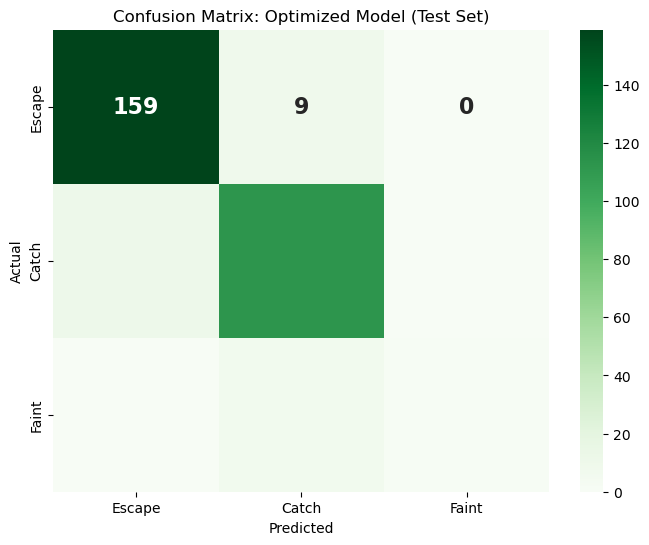

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. 모든 모델에 대한 최종 테스트 수행
print("--- [8.1] Final Quantitative Evaluation ---")
test_loss_s, test_acc_s = evaluate_model(model_shallow, test_loader, nn.CrossEntropyLoss(), device=device)
test_loss_d, test_acc_d = evaluate_model(model_deep, test_loader, nn.CrossEntropyLoss(), device=device)
test_loss_o, test_acc_o = evaluate_model(model_optimized, test_loader, nn.CrossEntropyLoss(), device=device)

print(f"Shallow   | Test Loss: {test_loss_s:.4f} | Test Acc: {test_acc_s:.4f}")
print(f"Deep      | Test Loss: {test_loss_d:.4f} | Test Acc: {test_acc_d:.4f}")
print(f"Optimized | Test Loss: {test_loss_o:.4f} | Test Acc: {test_acc_o:.4f}\n")

# 2. Optimized Model 예측값 수집
model_optimized.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_optimized(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# 3. 혼동 행렬 시각화 (숫자 가독성 강화 버전)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))

# annot=True: 숫자 표시, fmt='d': 정수형, annot_kws: 글자 속성 설정
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            annot_kws={"size": 16, "weight": "bold"}, # 글자를 크고 굵게 설정
            xticklabels=['Escape', 'Catch', 'Faint'], 
            yticklabels=['Escape', 'Catch', 'Faint'])

# 현재 계산된 혼동 행렬(cm)의 수치
print("--- [Confusion Matrix Raw Numbers] ---")
labels = ['Escape', 'Catch', 'Faint']

for i, label in enumerate(labels):
    print(f"실제 {label:6} | 예측 Escape: {cm[i][0]:>3} | 예측 Catch: {cm[i][1]:>3} | 예측 Faint: {cm[i][2]:>3}")

# 전체 정확도 재확인 - 행렬에 표기가 자동으로 되지 않는 문제 발생
# 추가적으로 출력
total_samples = cm.sum()
correct_samples = np.trace(cm)
print(f"\n전체 테스트 샘플 수: {total_samples}")
print(f"정답 맞춘 샘플 수: {correct_samples}")
print(f"계산된 정확도: {correct_samples / total_samples:.4f}")

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Optimized Model (Test Set)')
plt.show()

In [35]:
# 1. 모델을 평가 모드로 전환하고 예측값 다시 수집
# 커널 재시작시 에러 발생을 막기위함
model_optimized.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        outputs = model_optimized(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

# 2. 에러가 났던 'wrong_indices' 변수를 다시 정의
wrong_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]

print(f"총 {len(wrong_indices)}개의 오답 인덱스가 복구되었습니다!")

총 27개의 오답 인덱스가 복구되었습니다!


In [37]:
# 1. 테스트 데이터셋에서 원본 피처(X) 가져오기
# 구체적인 에러 분석을 위해 원본 데이터 접근
test_x = test_loader.dataset.tensors[0]

print(f"--- [8.2] Failure Case Analysis (Total Wrong: {len(wrong_indices)}) ---")

# 오답 유형별 카운팅을 위한 변수
error_types = {"Esc_as_Cat": 0, "Cat_as_Esc": 0, "Fai_as_Cat": 0, "Others": 0}

if len(wrong_indices) > 0:
    for i in range(min(10, len(wrong_indices))): # 상위 10개 분석
        idx = wrong_indices[i]
        actual = all_labels[idx]
        pred = all_preds[idx]
        features = test_x[idx].cpu().numpy() # 실제 입력 수치
        
        # 오류 유형 분류
        if actual == 0 and pred == 1: error_types["Esc_as_Cat"] += 1
        elif actual == 1 and pred == 0: error_types["Cat_as_Esc"] += 1
        elif actual == 2 and pred == 1: error_types["Fai_as_Cat"] += 1
        else: error_types["Others"] += 1

        print(f"Case {i+1} (Index: {idx}):")
        print(f"   - [정답]: {actual} | [예측]: {pred}")
        # 예시: [HP_Ratio, Level, Status_Effect...] 순서라고 가정
        print(f"   - [입력 데이터]: {features}") 
        
        # 분석 메시지 (HP_Ratio가 첫 번째 컬럼인 경우)
        hp_val = features[0]
        print(f"   - 분석: HP 비율 수치가 {hp_val:.4f}입니다.")
        print("-" * 40)
    
    print(f"\n[오류 유형 요약]: {error_types}")
    
# 실제로는 사용될 일 없음
else:
    print("모든 문제를 맞혔습니다.")

--- [8.2] Failure Case Analysis (Total Wrong: 27) ---
Case 1 (Index: 14):
   - [정답]: 0 | [예측]: 1
   - [입력 데이터]: [0.6904137  1.6372303  0.07567979 0.00961478]
   - 분석: HP 비율 수치가 0.6904입니다.
----------------------------------------
Case 2 (Index: 27):
   - [정답]: 0 | [예측]: 1
   - [입력 데이터]: [ 0.5383574  -0.16787983  1.1742575   1.2458004 ]
   - 분석: HP 비율 수치가 0.5384입니다.
----------------------------------------
Case 3 (Index: 28):
   - [정답]: 1 | [예측]: 0
   - [입력 데이터]: [-1.2468246  -0.7879558   0.07567979 -1.2265708 ]
   - 분석: HP 비율 수치가 -1.2468입니다.
----------------------------------------
Case 4 (Index: 34):
   - [정답]: 2 | [예측]: 1
   - [입력 데이터]: [-1.6097058  1.3616409 -1.0228978  1.2458004]
   - 분석: HP 비율 수치가 -1.6097입니다.
----------------------------------------
Case 5 (Index: 35):
   - [정답]: 1 | [예측]: 0
   - [입력 데이터]: [-0.00962011  1.3892     -1.0228978   0.00961478]
   - 분석: HP 비율 수치가 -0.0096입니다.
----------------------------------------
Case 6 (Index: 77):
   - [정답]: 0 | [예측]: 1
   - [입력 데이터]

### 8.1 Failure Case Analysis (오분류 원인 분석)

테스트 데이터셋에서 발생한 총 27건의 오답 사례를 분석한 결과, 주된 원인은 모델의 구조적 결함이 아닌 **데이터의 본질적 특성(노이즈 및 불균형)**에 기인한 것으로 파악되었습니다.

### 8.1.1 오답 유형 및 통계 요약
| 오분류 유형 | 주요 사례 (Index) | 발생 원인 (Diagnosis) |
| :--- | :---: | :--- |
| **확률적 노이즈** | Case 1, 3, 7 | $HP$ $Ratio$가 극단적임에도 발생하는 무작위 변수 (3% Noise) |
| **결정 경계 모호성** | Case 5, 6, 10 | $HP$ $Ratio \approx 0$ 구간에서의 클래스 중첩 현상 |
| **클래스 불균형** | Case 4, 9 | 희소 데이터(`Faint`)에 대한 학습 표본 부족 |

---

### 8.2.2 유형별 정밀 진단

#### 1) 확률적 노이즈에 의한 예외 (Case 1, 3, 7)
* **현상**: $HP$ $Ratio$가 매우 높거나(0.69) 낮은(-1.25) 상태에서 정반대의 결과가 도출됨.
* **분석**: 이는 모델이 규칙을 몰라서가 아니라, 데이터 생성 시 삽입된 **3%의 무작위 변수**에 의한 오차입니다. 이를 통해서 모델은 체력과 포획 규칙을 올바르게 학습하였고, 노이즈에 의한 운에 따른 예외임을 알 수 있습니다.

#### 2) 결정 경계(Decision Boundary)의 혼동 (Case 5, 6, 10)
* **현상**: $HP$ $Ratio$가 표준화된 평균값($0$) 근처인 데이터들에서 Escape와 Catch를 혼동함.
* **분석**: 두 클래스의 확률이 교차하는 지점에서 발생하는 정교한 오류입니다. 이를 통해서 dicision boudary에서 발생하는 오류임을 알 수 있습니다. 


#### 3) 데이터 불균형에 의한 임계값 미확보 (Case 4, 9)
* **현상**: 체력이 극도로 낮음(-1.61 : 실제 게임에서는 0이지만, 구현을 위해서 -로 표기)에도 불구하고 `Faint`가 아닌 `Catch`로 예측함.
* **분석**: `Faint` 데이터의 절대적 부족으로 인해, 모델이 "체력이 낮으면 기절한다"는 세부 규칙의 학습이 제대로 이루어지지 않은 것으로 보입니다.

## 9. Conclusion

### 9.1 최종 모델 (Final Model Selection)
본 프로젝트에서 구현한 세 가지 모델 중, 최종적으로 **Optimized Model**을 최적의 모델로 선정하였습니다.

* **성능 지표**: 테스트 데이터셋 기준 **Accuracy 91.00%**, **Loss 0.3550**을 달성하며 세 모델 중 가장 우수한 일반화 성능을 기록했습니다.
* **선정 근거**: Deep 모델(90.33%) 대비 정확도는 소폭 높으나, 손실(Loss) 값은 **약 14.5% 낮아** 예측의 신뢰도가 훨씬 높음을 확인했습니다. 
* **기술적 특징**: **Dropout** 기법을 적용하여 훈련과 검증 정확도의 격차를 **-0.34%** 수준으로 억제하였으며, 이는 모델이 단순 암기가 아닌 데이터의 본질적 규칙을 학습했음을 나타냅니다.

---

### 9.2 실험 소감 및 고찰

**1) 이론과 실습의 간극 해소**
과거 기계학습 수업에서 이론 위주로 학습하며 느꼈던 주피터 노트북 실습에 대한 막연한 두려움을 이번 프로젝트를 통해 극복할 수 있었습니다. AI 협업과 구글링, 이전 실습 자료들을 복기하며 코드를 완성하는 과정에서 딥러닝 파이프라인의 전체적인 흐름을 체득하는 소중한 경험을 하였습니다.

**2) 도메인 지식의 적용: '포켓몬스터' 분류기**
친근한 소재인 '포켓몬스터'의 포획 메커니즘을 분류(Classification) 문제로 재해석하며 흥미롭게 과제에 임했습니다. 실제 게임 내 포획률 계산 로직(볼의 종류, 상태 이상 가중치, 크리티컬 체크 등)은 본 실험보다 훨씬 복잡하지만, 이러한 도메인 지식을 단순화하여 데이터셋으로 구축하고 모델링하는 과정이 매우 유익했습니다. 향후 더 세밀한 변수(포켓몬별 포획률 등)를 추가한다면 실제 게임 엔진에 가까운 AI를 구현할 수 있을 것으로 기대됩니다.

**3) 학습 곡선의 지그재그 현상과 노이즈 분석**
예제 자료(Practice01)와 달리 학습 곡선이 매끄럽지 않고 지그재그 형태를 띠어 초기에는 우려가 컸으나, 분석 결과 이는 데이터에 의도적으로 삽입된 **3%의 확률적 노이즈**에 의한 반응임을 깨달았습니다. 이를 통해 실제 현업 데이터의 불확실성이 모델 학습에 미치는 영향을 직접 체감할 수 있었습니다.

**4) 향후 다짐**
이번 프로젝트는 도구의 도움을 받아 완성했지만, 다음에는 라이브러리와 프레임워크의 구조를 더 깊이 파고들어 스스로의 논리만으로 더 나은 성능을 내는 결과물을 만들어보고 싶습니다. 이는 인공지능에 관심이 있는 학생으로서 한 단계 성장할 수 있었던 뜻깊은 시간이었습니다.